In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 39 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (22.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121753 files and direc

In [ ]:
import pandas as pd
import numpy as np

# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns

In [ ]:
plt.rc('font', family='NanumBarunGothic')

In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mem = pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/realfinalmem.csv")

In [ ]:
mem.head()

,Unnamed: 0,회원번호,조합원상태,시,주소,성별,연령,연령대,배송서비스신청여부,모바일알람여부,Gold_member,Grade
0,0,1000012800,정상회원,용인,수지구-풍덕천동,여,58.0,50대,미신청,.,normal,green
1,1,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal,gold
2,2,1000122304,정상회원,광주,광주-기타,여,38.0,30대,미신청,.,normal,gold
3,3,1000163136,정상회원,용인,수지구-동천동,여,73.0,70대,미신청,.,normal,gold
4,4,1000281920,정상회원,용인,수지구-풍덕천동,여,42.0,40대,신청,.,normal,gold


In [ ]:
mkt = pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/전체매장데이터.csv")
mkt.head()

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
0,2023-01-06,220954944,정상회원,반찬,두부/유부,두부,두부(1모:420g),1.0,3829,매장A,10:32:00,NaN,1,6,10,0
1,2023-01-06,89023040,정상회원,채소,열매채소,단호박/손질,단호박(깍뚝썰기/300g),1.0,4977,매장A,10:41:00,NaN,1,6,10,0
2,2023-01-06,354941440,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,11:00:00,NaN,1,6,11,0
3,2023-01-06,786634048,탈퇴,반찬,어묵/묵,묵,도토리묵(420g:1모),1.0,7083,매장A,11:28:00,NaN,1,6,11,0
4,2023-01-06,438543104,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,11:59:00,NaN,1,6,11,0


In [ ]:
member= mkt.groupby('회원번호').agg({'구매금액': 'sum', '공급일자': lambda x: x.nunique(), '반품일자': 'count', '구매매장': lambda x: x.mode()[0]})

member.head()

,구매금액,공급일자,반품일자,구매매장
회원번호,,,,
18613824,21059,1,0,매장C
18764160,-88827,8,2,매장D
18792000,33311,1,0,매장C
18942336,560920,12,0,매장D
18949760,2776,1,0,매장C


In [ ]:
member.columns = ['총구매금액','방문 횟수','반품횟수','구매매장']

In [ ]:
member

,총구매금액,방문 횟수,반품횟수,구매매장
회원번호,,,,
18613824,21059,1,0,매장C
18764160,-88827,8,2,매장D
18792000,33311,1,0,매장C
18942336,560920,12,0,매장D
18949760,2776,1,0,매장C
...,...,...,...,...
1644772352,85000,1,0,매장B
1644957952,25079,1,0,매장D
1670400000,13060734,281,70,매장C


In [ ]:
df = pd.merge(mem,member,how='left', on=['회원번호'])
df

,Unnamed: 0,회원번호,조합원상태,시,주소,성별,연령,연령대,배송서비스신청여부,모바일알람여부,Gold_member,Grade,총구매금액,방문 횟수,반품횟수,구매매장
0,0,1000012800,정상회원,용인,수지구-풍덕천동,여,58.0,50대,미신청,.,normal,green,7658,1,0,매장B
1,1,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal,gold,36948,1,0,매장C
2,2,1000122304,정상회원,광주,광주-기타,여,38.0,30대,미신청,.,normal,gold,142831,15,0,매장C
3,3,1000163136,정상회원,용인,수지구-동천동,여,73.0,70대,미신청,.,normal,gold,138892,4,0,매장A
4,4,1000281920,정상회원,용인,수지구-풍덕천동,여,42.0,40대,신청,.,normal,gold,592543,28,2,매장C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11550,11550,999682432,탈퇴,용인,수지구-동천동,여,47.0,40대,미신청,.,normal,green,39246,1,0,매장A
11551,11551,999721408,정상회원,용인,수지구-동천동,여,43.0,40대,미신청,.,normal,green,39820,3,1,매장A
11552,11552,999738112,정상회원,용인,수지구-성복동,여,67.0,60대,미신청,.,normal,gold,152960,9,0,매장D
11553,11553,999754816,정상회원,용인,수지구-상현동,여,44.0,40대,신청,.,normal,vip,641334,21,0,매장B


In [ ]:
df.groupby('조합원상태')['총구매금액'].sum()

조합원상태
정상회원     3222496749
탈퇴         32101624
탈퇴신청         130467
탈퇴처리중        427583
Name: 총구매금액, dtype: int64

In [ ]:
df = df[['조합원상태','성별','연령대','배송서비스신청여부','모바일알람여부','총구매금액','방문 횟수','반품횟수']]
df

,조합원상태,성별,연령대,배송서비스신청여부,모바일알람여부,총구매금액,방문 횟수,반품횟수
0,정상회원,여,50대,미신청,.,7658,1,0
1,정상회원,여,30대,미신청,.,36948,1,0
2,정상회원,여,30대,미신청,.,142831,15,0
3,정상회원,여,70대,미신청,.,138892,4,0
4,정상회원,여,40대,신청,.,592543,28,2
...,...,...,...,...,...,...,...,...
11550,탈퇴,여,40대,미신청,.,39246,1,0
11551,정상회원,여,40대,미신청,.,39820,3,1
11552,정상회원,여,60대,미신청,.,152960,9,0
11553,정상회원,여,40대,신청,.,641334,21,0


In [ ]:
df['조합원상태'].value_counts()

정상회원     11413
탈퇴         139
탈퇴처리중        2
탈퇴신청         1
Name: 조합원상태, dtype: int64

In [ ]:
df['조합원상태'].replace(['탈퇴처리중','탈퇴신청'],'탈퇴', inplace=True)

In [ ]:
df['조합원상태'].value_counts()

정상회원    11413
탈퇴        142
Name: 조합원상태, dtype: int64

In [ ]:
df['모바일알람여부'].replace(['.'], '미수신', inplace=True)
df['모바일알람여부'].value_counts()

미수신    10653
수신       902
Name: 모바일알람여부, dtype: int64

분류모델 생성

In [ ]:
# scaling
from sklearn.preprocessing import StandardScaler
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 로지스틱 회귀
from statsmodels.api import Logit
import statsmodels.api as sm
# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import export_graphviz
from sklearn.neighbors import KNeighborsClassifier
import graphviz

In [ ]:
df['조합원상태'].replace(['탈퇴'],1,inplace = True)
df['조합원상태'].replace(['정상회원'],0, inplace= True)

df.head()

,조합원상태,성별,연령대,배송서비스신청여부,모바일알람여부,총구매금액,방문 횟수,반품횟수
0,0,여,50대,미신청,미수신,7658,1,0
1,0,여,30대,미신청,미수신,36948,1,0
2,0,여,30대,미신청,미수신,142831,15,0
3,0,여,70대,미신청,미수신,138892,4,0
4,0,여,40대,신청,미수신,592543,28,2


In [ ]:
df_char = df.select_dtypes(include = "object")
df_numeric = df.select_dtypes(exclude = "object")

df_dummy = pd.get_dummies(df_char)


# 더미화된 문자 데이터 + 숫자 데이터
df_scaled = pd.concat([df_numeric, df_dummy],axis = 1)
df_scaled.head()

,조합원상태,총구매금액,방문 횟수,반품횟수,성별_남,성별_여,연령대_20대,연령대_20대 이하,연령대_30대,연령대_40대,연령대_50대,연령대_60대,연령대_70대,연령대_80대 이상,배송서비스신청여부_미신청,배송서비스신청여부_신청,모바일알람여부_미수신,모바일알람여부_수신
0,0,7658,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0
1,0,36948,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0
2,0,142831,15,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0
3,0,138892,4,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0
4,0,592543,28,2,0,1,0,0,0,1,0,0,0,0,0,1,1,0


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report

In [ ]:
df_scaled_x = df_scaled.drop('조합원상태', axis = 1)
df_scaled_y = df_scaled['조합원상태']

In [ ]:
# ROS를 적용합니다.
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(df_scaled_x, df_scaled_y)


In [ ]:
#데이터 분할

X_train, X_test, y_train, y_test = train_test_split(X_ros, y_ros, test_size = 0.2, random_state = 1234)

In [ ]:
# 랜덤 포레스트 모델을 정의합니다.
rf_model = RandomForestClassifier(random_state=42)

# 그리드 서치에 사용할 파라미터 그리드를 정의합니다.
param_grid = {
    'n_estimators': [50, 100, 150],  # 트리의 개수
    'max_depth': [5, 10, 15],  # 트리의 최대 깊이
    'min_samples_split': [2, 5, 10],  # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4]  # 리프 노드에 필요한 최소 샘플 수
}

# 그리드 서치를 수행합니다.
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='f1')

In [ ]:


# RandomForestClassifier 객체 생성
best_rf = RandomForestClassifier(max_depth= 5, min_samples_leaf=1, min_samples_split = 2, n_estimators= 100)
final_rf = best_rf.fit(X_train, y_train)
# 테스트 데이터로 최적 모델을 평가합니다.
y_pred = final_rf.predict(X_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.70      0.73      0.72      2287
           1       0.72      0.69      0.70      2279

    accuracy                           0.71      4566
   macro avg       0.71      0.71      0.71      4566
weighted avg       0.71      0.71      0.71      4566



In [ ]:
# 훈련 데이터에 대한 예측 및 정확도, F1 스코어 계산
train_pred = final_rf.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)

# 테스트 데이터에 대한 예측 및 정확도, F1 스코어 계산
test_pred = final_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

# 결과를 데이터프레임으로 저장
df_results = pd.DataFrame({
    'acc_train': [train_accuracy],
    'f1_train': [train_f1],
    'acc_test': [test_accuracy],
    'f1_test': [test_f1]
}, index=['RandomForest'])

# 결과 출력
df_results

,acc_train,f1_train,acc_test,f1_test
RandomForest,0.710734,0.703058,0.710031,0.703272


In [ ]:
# 설명변수 중요도 확인
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = final_rf.feature_importances_
feature_importance.sort_values(by="importance", ascending=False)

,feature,importance
0,총구매금액,0.401811
1,방문 횟수,0.272787
2,반품횟수,0.068855
7,연령대_30대,0.053631
15,모바일알람여부_미수신,0.032007
12,연령대_80대 이상,0.025455
11,연령대_70대,0.024009
16,모바일알람여부_수신,0.023979
10,연령대_60대,0.019542
3,성별_남,0.014468


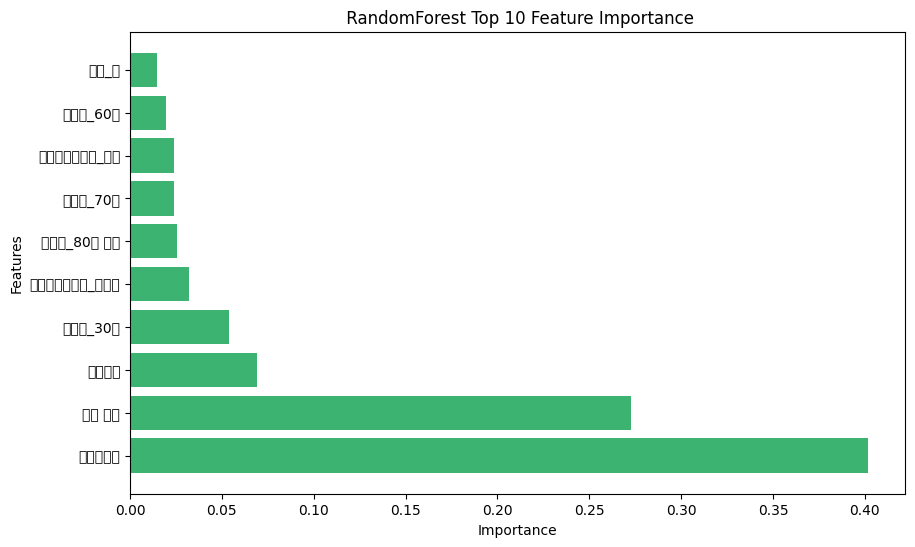

In [ ]:
import matplotlib.pyplot as plt

# 설명변수 중요도를 확인하기 위한 DataFrame 생성
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = final_rf.feature_importances_

# 중요도에 따라 내림차순으로 정렬
feature_importance_sorted = feature_importance.sort_values(by="importance", ascending=False)

# 상위 10개의 데이터만 선택
top_10_features = feature_importance_sorted.head(10)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["feature"], top_10_features["importance"],color='mediumseagreen')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title(' RandomForest Top 10 Feature Importance')
plt.show()

In [ ]:
y_pred_train = final_rf.predict(X_train)
y_pred_train

array([0, 0, 0, ..., 1, 1, 0])

그래디언트 부스팅

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# 그래디언트 부스팅 모델을 정의합니다.
gb_model = GradientBoostingClassifier(random_state=42)

# 그리드 서치에 사용할 파라미터 그리드를 정의합니다.
param_grid = {
    'n_estimators': [50, 100, 150],  # 트리의 개수
    'learning_rate': [ 0.1, 0.15],  # 학습률
    'max_depth': [3, 5, 7],  # 트리의 최대 깊이
    'min_samples_split': [2, 5, 10],  # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4]  # 리프 노드에 필요한 최소 샘플 수
}

# 그리드 서치를 수행합니다.
grid_search = GridSearchCV(gb_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.15], 'max_depth': [3, 5, 7],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='f1')

In [ ]:
# 최적의 모델을 선택합니다.
best_gb_model = GradientBoostingClassifier(learning_rate=0.5,max_depth=5, n_estimators=300)

best_gb = best_gb_model.fit(X_train, y_train)

# 테스트 데이터로 최적 모델을 평가합니다.
y_pred_gb = best_gb.predict(X_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.70      0.73      0.72      2287
           1       0.72      0.69      0.70      2279

    accuracy                           0.71      4566
   macro avg       0.71      0.71      0.71      4566
weighted avg       0.71      0.71      0.71      4566



In [ ]:
# GradientBoosting 모델에 대한 성능 측정
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

# GradientBoosting 모델의 결과를 데이터프레임에 추가
df_results.loc['GradientBoosting'] = [accuracy_gb, f1_gb, accuracy_gb, f1_gb]

In [ ]:
df_results

,acc_train,f1_train,acc_test,f1_test
RandomForest,0.710734,0.703058,0.710031,0.703272
GradientBoosting,0.990802,0.990870,0.990802,0.990870


In [ ]:
# 설명변수 중요도 확인
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = best_gb_model.feature_importances_
feature_importance.sort_values(by="importance", ascending=False)

,feature,importance
0,총구매금액,0.670973
1,방문 횟수,0.137681
2,반품횟수,0.036085
7,연령대_30대,0.028767
9,연령대_50대,0.023851
8,연령대_40대,0.023259
10,연령대_60대,0.021356
11,연령대_70대,0.014887
12,연령대_80대 이상,0.011282
16,모바일알람여부_수신,0.010172


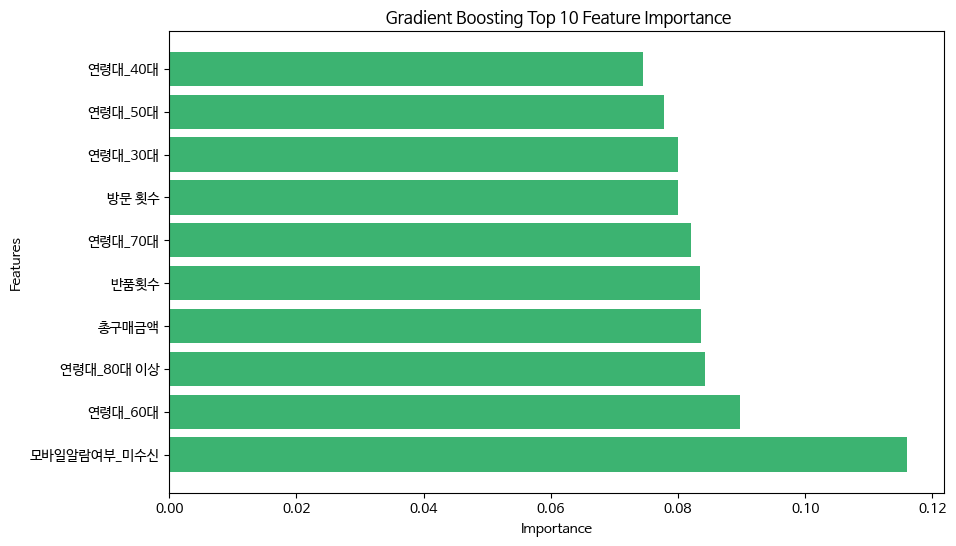

In [ ]:
import matplotlib.pyplot as plt

# 설명변수 중요도를 확인하기 위한 DataFrame 생성
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = best_gb_model.feature_importances_

# 중요도에 따라 내림차순으로 정렬
feature_importance_sorted = feature_importance.sort_values(by="importance", ascending=False)

# 상위 10개의 데이터만 선택
top_10_features = feature_importance_sorted.head(10)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["feature"], top_10_features["importance"],color='mediumseagreen')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title(' Gradient Boosting Top 10 Feature Importance')
plt.show()

XGBoost

In [ ]:
# xgboost 패키지 불러오기
from xgboost import XGBClassifier


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import numpy as np

# XGBoost 모델 정의
xgb_model = XGBClassifier()

# 그리드 서치에 사용할 하이퍼파라미터 그리드 정의
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5],
    'gamma': [0, 0.1, 0.2]
}

# 그리드 서치 객체 생성
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='f1', cv=5, verbose=1, n_jobs=-1)



# 그리드 서치를 통한 모델 학습
grid_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=10, eval_metric="logloss")

# 최적의 모델 출력
print("최적의 하이퍼파라미터:", grid_search.best_params_)

# 최적의 모델로 예측 수행
y_pred = grid_search.predict(X_test)

# F1 점수 출력
print("최적의 모델 F1 점수:", f1_score(y_test, y_pred))


Fitting 5 folds for each of 81 candidates, totalling 405 fits
[0]	validation_0-logloss:0.66890
[1]	validation_0-logloss:0.64885
[2]	validation_0-logloss:0.63040
[3]	validation_0-logloss:0.61656
[4]	validation_0-logloss:0.60443
[5]	validation_0-logloss:0.59005
[6]	validation_0-logloss:0.57969
[7]	validation_0-logloss:0.57011
[8]	validation_0-logloss:0.56165
[9]	validation_0-logloss:0.55444
[10]	validation_0-logloss:0.54796
[11]	validation_0-logloss:0.54186
[12]	validation_0-logloss:0.53612
[13]	validation_0-logloss:0.52691
[14]	validation_0-logloss:0.52357
[15]	validation_0-logloss:0.51924
[16]	validation_0-logloss:0.51138
[17]	validation_0-logloss:0.50831
[18]	validation_0-logloss:0.50464
[19]	validation_0-logloss:0.50168
[20]	validation_0-logloss:0.49991
[21]	validation_0-logloss:0.49570
[22]	validation_0-logloss:0.49350
[23]	validation_0-logloss:0.48645
[24]	validation_0-logloss:0.48523
[25]	validation_0-logloss:0.48197
[26]	validation_0-logloss:0.47713
[27]	validation_0-logloss:0.47

In [ ]:
# 사용자 모델 생성
xgboost_final= XGBClassifier(gamma= 0.1, learning_rate= 0.15, max_depth= 5, n_estimators= 300, random_state=1234)
# 모델 적합
xgboost_final.fit(X_train, y_train)

# 예측 및 모델 평가:Train
xgb_pred_train = xgboost_final.predict(X_train)


print('\n',classification_report(y_train, xgb_pred_train))


# 예측 및 모델 평가:Test
xgb_pred_test = xgboost_final.predict(X_test)

print('\n',classification_report(y_test, xgb_pred_test))


               precision    recall  f1-score   support

           0       1.00      0.93      0.96      9126
           1       0.93      1.00      0.97      9134

    accuracy                           0.96     18260
   macro avg       0.97      0.96      0.96     18260
weighted avg       0.97      0.96      0.96     18260


               precision    recall  f1-score   support

           0       1.00      0.91      0.95      2287
           1       0.92      1.00      0.96      2279

    accuracy                           0.96      4566
   macro avg       0.96      0.96      0.96      4566
weighted avg       0.96      0.96      0.96      4566



In [ ]:
# GradientBoosting 모델에 대한 성능 측정
accuracy_xgb = accuracy_score(y_test, xgb_pred_test)
f1_xgb = f1_score(y_test, xgb_pred_test)

# GradientBoosting 모델의 결과를 데이터프레임에 추가
df_results.loc['XGBoost'] = [accuracy_xgb, f1_xgb, accuracy_xgb, f1_xgb]

In [ ]:
df_results

,acc_train,f1_train,acc_test,f1_test
RandomForest,0.710734,0.703058,0.710031,0.703272
GradientBoosting,0.990802,0.990870,0.990802,0.990870
XGBoost,0.956198,0.957966,0.956198,0.957966


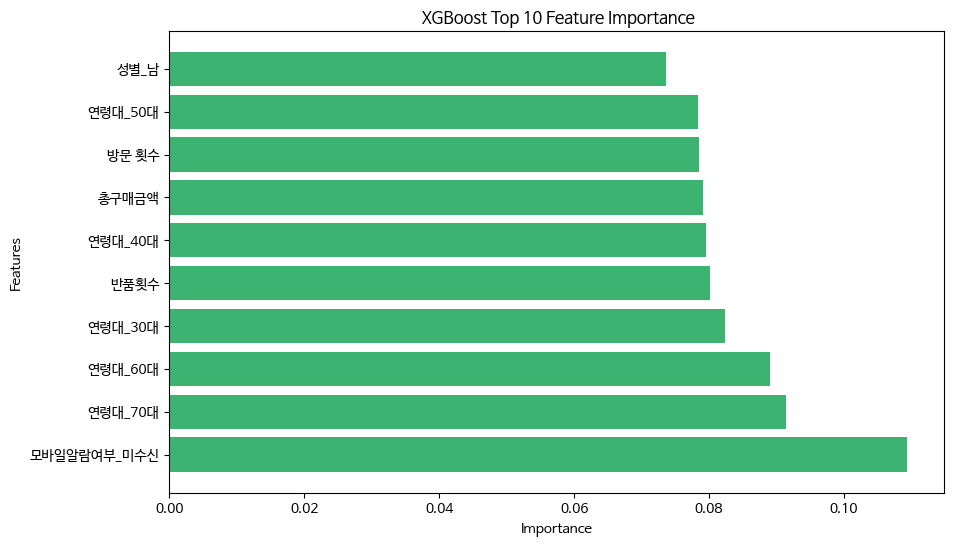

In [ ]:
import matplotlib.pyplot as plt

# 설명변수 중요도를 확인하기 위한 DataFrame 생성
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = xgboost_final.feature_importances_

# 중요도에 따라 내림차순으로 정렬
feature_importance_sorted = feature_importance.sort_values(by="importance", ascending=False)

# 상위 10개의 데이터만 선택
top_10_features = feature_importance_sorted.head(10)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["feature"], top_10_features["importance"],color='mediumseagreen')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title(' XGBoost Top 10 Feature Importance')
plt.show()

성능 시각화 비교

In [ ]:
from sklearn.metrics import f1_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

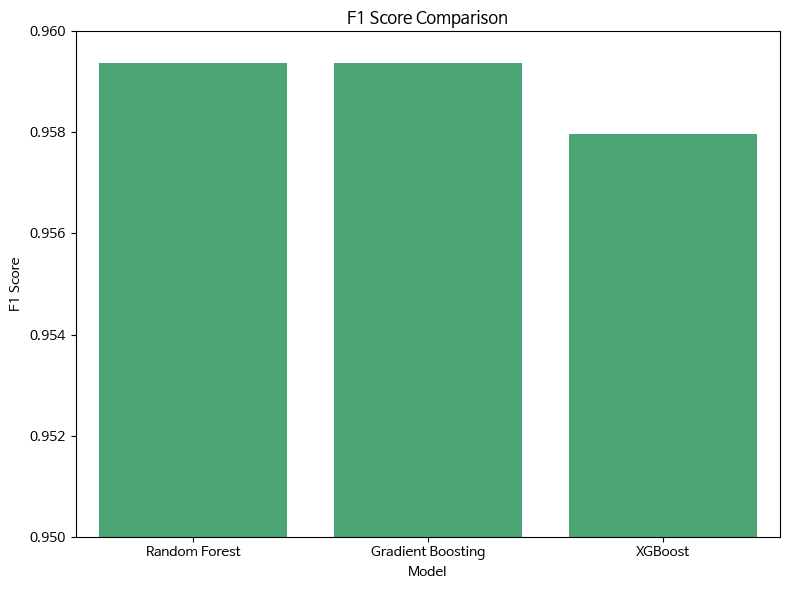

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 성능 지표 데이터를 데이터프레임으로 생성
data = {
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost'],
    'F1 Score': [0.959377, 0.959377, 0.957966]
}
performance_df = pd.DataFrame(data)

# 그래프를 그릴 준비를 합니다.
plt.figure(figsize=(8, 6))

# F1 Score를 시각화합니다.
sns.barplot(data=performance_df, x='Model', y='F1 Score', color='mediumseagreen')

# y 축의 범위를 조정합니다.
plt.ylim(0.95, 0.96)

# 그래프 타이틀과 레이블을 설정합니다.
plt.title('F1 Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1 Score')

# 그래프를 표시합니다.
plt.tight_layout()
plt.show()
